After transient: ic_1 = [-15.55737418  -7.89614891  42.93255568]
After transient: ic_2 = [-11.64080274 -15.79233406  25.70151518]
Simulation: 4000 steps, dt = 0.01, alpha = 0.5
  IC 1 = [-8.  9.  2.]
  IC 2 = [ 6. -7. 24.]
  E (after 500-step transient) = 23.4860
  E (second half only)                 = 23.5122
  ||x1 - x2|| at start                 = 19.3545
  ||x1 - x2|| at end                   = 23.5092


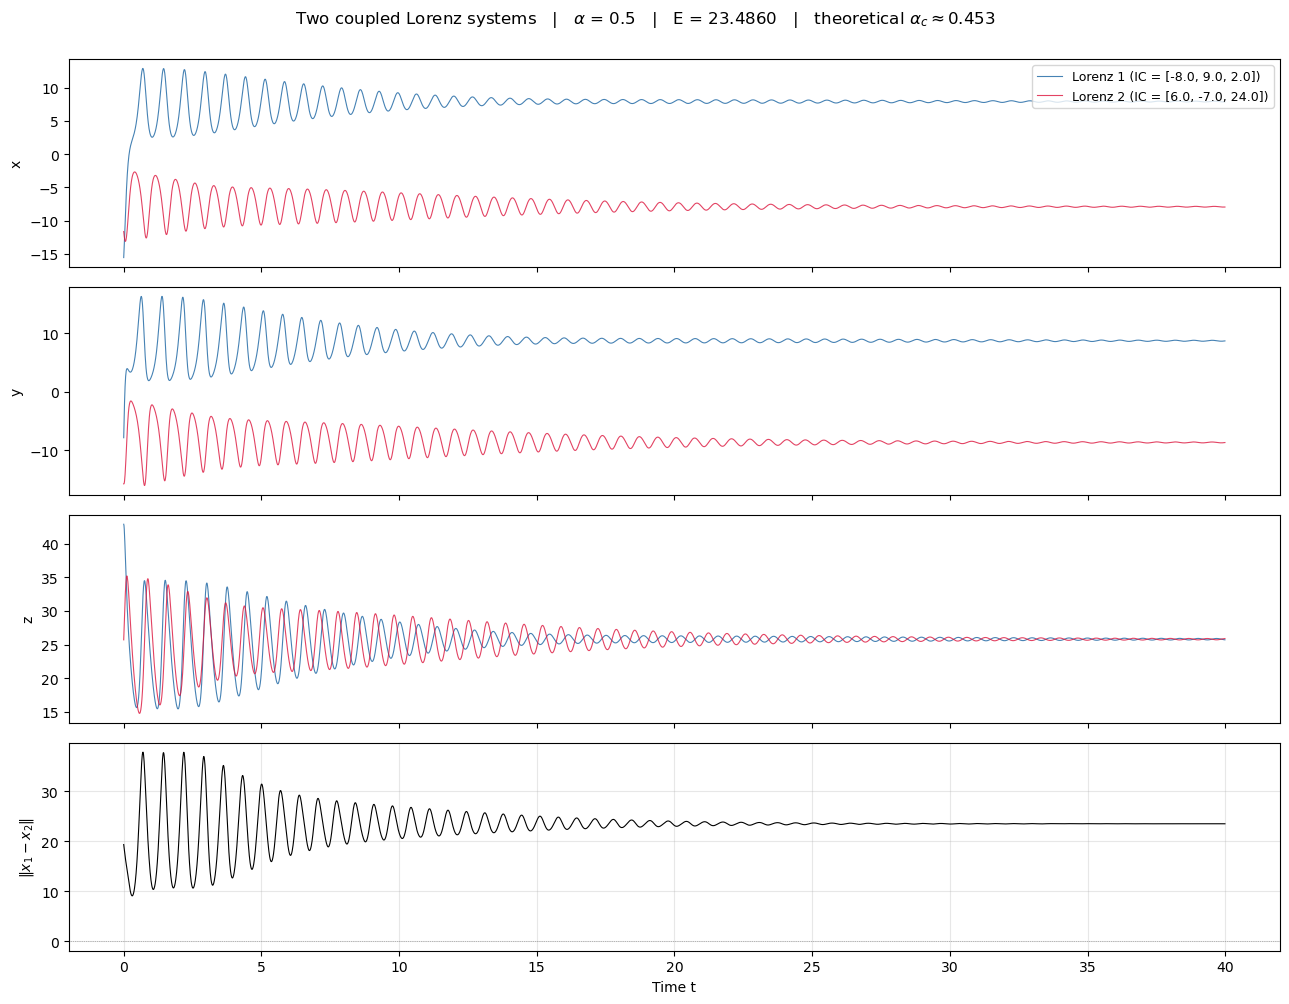

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# ADJUSTABLE PARAMETERS — change these and re-run the cell
# ==========================================================
alpha = 0.5       # coupling strength (0 = uncoupled)

# Initial conditions for the two Lorenz systems (any 3-vector on/near the attractor)
ic_1 = np.array([ -8.0,  9.0, 2.0])
ic_2 = np.array([  6.0, -7.0, 24.0])

# Lorenz parameters (classical chaotic regime)
sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0

# Integration
dt          = 0.01      # time step
n_steps     = 4000      # total integration steps to compute
plot_steps  = 10000      # how many steps of the result to display
transient   = 500       # discard this many steps before computing E

# ==========================================================
# DISCARD TRANSIENTS — get both ICs onto the chaotic attractor
# ==========================================================
def integrate_uncoupled(x0, n_transient, dt, sigma, rho, beta):
    """Integrate uncoupled Lorenz to land on the attractor."""
    x = x0.copy()
    for _ in range(n_transient):
        # RK4 for single Lorenz (alpha = 0 gives uncoupled)
        k1 = lorenz_rhs(x,            sigma, rho, beta)
        k2 = lorenz_rhs(x + 0.5*dt*k1, sigma, rho, beta)
        k3 = lorenz_rhs(x + 0.5*dt*k2, sigma, rho, beta)
        k4 = lorenz_rhs(x + dt*k3,     sigma, rho, beta)
        x = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return x

n_transient = 5000   # 50 time units, ~45 Lyapunov times
ic_1_on_attractor = integrate_uncoupled(ic_1, n_transient, dt, sigma, rho, beta)
ic_2_on_attractor = integrate_uncoupled(ic_2, n_transient + 500, dt, sigma, rho, beta)
# +500 offset for ic_2 ensures it's on a different part of the attractor

print(f"After transient: ic_1 = {ic_1_on_attractor}")
print(f"After transient: ic_2 = {ic_2_on_attractor}")

# Use these as the actual initial conditions for the coupled run
x1 = ic_1_on_attractor.copy()
x2 = ic_2_on_attractor.copy()

# ==========================================================
# COUPLED LORENZ DYNAMICS  (Eq. 6 with H = I)
# ==========================================================
# dx_i/dt = f(x_i) + alpha * (x_j - x_i)     for i=1,2  and j the other one
def lorenz_rhs(x, sigma, rho, beta):
    """Standard Lorenz vector field f(x), x = (x, y, z)."""
    return np.array([
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1] - beta * x[2],
    ])

def coupled_rhs(x1, x2, sigma, rho, beta, alpha):
    f1 = lorenz_rhs(x1, sigma, rho, beta)
    f2 = lorenz_rhs(x2, sigma, rho, beta)
    # Diffusive coupling, identity coupling matrix H = I
    dx1 = f1 + alpha * (x2 - x1)
    dx2 = f2 + alpha * (x1 - x2)
    return dx1, dx2

# Fourth-order Runge-Kutta step for the joint (x1, x2) system
def rk4_step(x1, x2, dt, sigma, rho, beta, alpha):
    k1_1, k1_2 = coupled_rhs(x1,                x2,                sigma, rho, beta, alpha)
    k2_1, k2_2 = coupled_rhs(x1 + 0.5*dt*k1_1,  x2 + 0.5*dt*k1_2,  sigma, rho, beta, alpha)
    k3_1, k3_2 = coupled_rhs(x1 + 0.5*dt*k2_1,  x2 + 0.5*dt*k2_2,  sigma, rho, beta, alpha)
    k4_1, k4_2 = coupled_rhs(x1 + dt*k3_1,      x2 + dt*k3_2,      sigma, rho, beta, alpha)
    x1_next = x1 + (dt / 6.0) * (k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
    x2_next = x2 + (dt / 6.0) * (k1_2 + 2*k2_2 + 2*k3_2 + k4_2)
    return x1_next, x2_next

# ==========================================================
# RUN THE SIMULATION
# ==========================================================
y1_traj = np.zeros((n_steps, 3))
y2_traj = np.zeros((n_steps, 3))

for t in range(n_steps):
    y1_traj[t] = x1
    y2_traj[t] = x2
    x1, x2 = rk4_step(x1, x2, dt, sigma, rho, beta, alpha)

# ==========================================================
# DIAGNOSTICS  (Eq. 15 of the paper, in physical units)
# ==========================================================
diff = np.linalg.norm(y1_traj - y2_traj, axis=1)
E_full = float(np.mean(diff[transient:]))
E_late = float(np.mean(diff[len(diff) // 2:]))

print(f"Simulation: {n_steps} steps, dt = {dt}, alpha = {alpha}")
print(f"  IC 1 = {ic_1}")
print(f"  IC 2 = {ic_2}")
print(f"  E (after {transient}-step transient) = {E_full:.4f}")
print(f"  E (second half only)                 = {E_late:.4f}")
print(f"  ||x1 - x2|| at start                 = {diff[0]:.4f}")
print(f"  ||x1 - x2|| at end                   = {diff[-1]:.4f}")

# ==========================================================
# PLOT: 3 COMPONENTS OVERLAID + DISTANCE OVER TIME
# ==========================================================
n_plot = min(plot_steps, n_steps)
t_axis = np.arange(n_plot) * dt
dim_names = ['x', 'y', 'z']

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

for d in range(3):
    ax = axes[d]
    ax.plot(t_axis, y1_traj[:n_plot, d], color='steelblue',
            linewidth=0.8, label=f'Lorenz 1 (IC = {ic_1.tolist()})')
    ax.plot(t_axis, y2_traj[:n_plot, d], color='crimson',
            linewidth=0.8, alpha=0.8,
            label=f'Lorenz 2 (IC = {ic_2.tolist()})')
    ax.set_ylabel(dim_names[d])
    if d == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[3].plot(t_axis, diff[:n_plot], color='black', linewidth=0.8)
axes[3].set_ylabel(r'$\|x_1 - x_2\|$')
axes[3].axhline(0, color='gray', linestyle=':', linewidth=0.5)
axes[3].grid(alpha=0.3)

axes[-1].set_xlabel('Time t')

fig.suptitle(
    f'Two coupled Lorenz systems   |   '
    fr'$\alpha$ = {alpha}   |   '
    f'E = {E_full:.4f}   |   '
    fr'theoretical $\alpha_c \approx 0.453$',
    y=1.00
)
plt.tight_layout()
plt.savefig("lorenz_fixed_point.png")
plt.show()

Pre-generating 10 pairs of attractor-landed ICs...
Done.

Sweeping alpha over 60 values, 10 realisations each (600 runs total)...
  alpha = 0.300   mean E =  10.737   median E =  11.177   min E =   6.870   [   1.3s, ~  77.1s left]
  alpha = 0.305   mean E =  10.624   median E =  11.087   min E =   4.259   [   2.6s, ~  76.2s left]
  alpha = 0.310   mean E =   9.853   median E =   9.480   min E =   7.621   [   4.0s, ~  75.6s left]
  alpha = 0.315   mean E =  11.021   median E =  10.829   min E =   8.492   [   5.3s, ~  74.0s left]
  alpha = 0.320   mean E =  11.295   median E =  11.441   min E =   4.355   [   6.6s, ~  72.4s left]
  alpha = 0.325   mean E =  10.612   median E =   9.949   min E =   8.208   [   7.9s, ~  70.9s left]
  alpha = 0.330   mean E =  12.976   median E =  11.708   min E =   6.672   [   9.2s, ~  69.4s left]
  alpha = 0.335   mean E =  10.202   median E =   9.469   min E =   6.251   [  10.5s, ~  68.0s left]
  alpha = 0.340   mean E =  12.254   median E =  10.475   min 

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/sync_diagram.png'

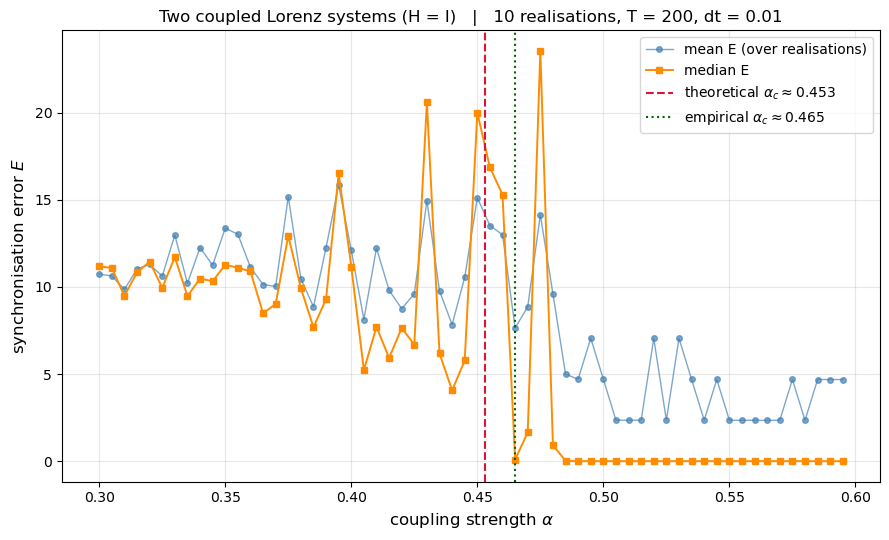

In [17]:
"""
Alpha sweep for two diffusively coupled Lorenz systems (H = I).
Reproduces Figure 3(a) of Eroglu, Lamb & Pereira, Contemp. Phys. 58, 207 (2017).

Theoretical critical coupling: alpha_c = Lambda / 2 ~ 0.453
(from the maximum Lyapunov exponent Lambda ~ 0.906 of the Lorenz attractor).
"""

import numpy as np
import matplotlib.pyplot as plt
from time import time

# ==========================================================
# LORENZ DYNAMICS
# ==========================================================
SIGMA, RHO, BETA = 10.0, 28.0, 8.0 / 3.0


def lorenz_rhs(x, sigma=SIGMA, rho=RHO, beta=BETA):
    """Standard Lorenz vector field."""
    return np.array([
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1] - beta * x[2],
    ])


def coupled_rhs(x1, x2, alpha, sigma=SIGMA, rho=RHO, beta=BETA):
    """Diffusively coupled Lorenz pair, H = I (identity coupling)."""
    f1 = lorenz_rhs(x1, sigma, rho, beta)
    f2 = lorenz_rhs(x2, sigma, rho, beta)
    return f1 + alpha * (x2 - x1), f2 + alpha * (x1 - x2)


def rk4_step_coupled(x1, x2, dt, alpha):
    """One RK4 step of the coupled (x1, x2) system."""
    k1_1, k1_2 = coupled_rhs(x1, x2, alpha)
    k2_1, k2_2 = coupled_rhs(x1 + 0.5 * dt * k1_1, x2 + 0.5 * dt * k1_2, alpha)
    k3_1, k3_2 = coupled_rhs(x1 + 0.5 * dt * k2_1, x2 + 0.5 * dt * k2_2, alpha)
    k4_1, k4_2 = coupled_rhs(x1 + dt * k3_1, x2 + dt * k3_2, alpha)
    x1_n = x1 + (dt / 6.0) * (k1_1 + 2 * k2_1 + 2 * k3_1 + k4_1)
    x2_n = x2 + (dt / 6.0) * (k1_2 + 2 * k2_2 + 2 * k3_2 + k4_2)
    return x1_n, x2_n


def rk4_step_uncoupled(x, dt):
    """One RK4 step of an isolated Lorenz system."""
    k1 = lorenz_rhs(x)
    k2 = lorenz_rhs(x + 0.5 * dt * k1)
    k3 = lorenz_rhs(x + 0.5 * dt * k2)
    k4 = lorenz_rhs(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def land_on_attractor(x0, n_transient, dt):
    """Integrate uncoupled Lorenz to land on the chaotic attractor."""
    x = x0.copy()
    for _ in range(n_transient):
        x = rk4_step_uncoupled(x, dt)
    return x


# ==========================================================
# SYNCHRONISATION ERROR FOR ONE (alpha, IC) REALISATION
# ==========================================================
def synchronisation_error(alpha, ic1, ic2, dt, n_steps, transient_steps,
                          sigma=SIGMA, rho=RHO, beta=BETA):
    """
    Run the coupled system, return time-averaged ||x1 - x2|| (Eq. 15)
    after discarding `transient_steps` initial steps.

    RK4 inlined with scalar component arithmetic to avoid the per-step
    overhead of np.array allocation in the hot loop. This is ~10x faster
    than the function-based version for long runs.
    """
    x1, y1, z1 = ic1
    x2, y2, z2 = ic2
    half = 0.5 * dt
    sixth = dt / 6.0

    # Accumulators for the time average (avoid storing the whole trajectory)
    diff_sum = 0.0
    n_avg = n_steps - transient_steps

    for t in range(n_steps):
        # Synchronisation error at this step
        dx, dy, dz = x1 - x2, y1 - y2, z1 - z2
        if t >= transient_steps:
            diff_sum += (dx * dx + dy * dy + dz * dz) ** 0.5

        # ----- k1 -----
        f1x = sigma * (y1 - x1) + alpha * (x2 - x1)
        f1y = x1 * (rho - z1) - y1 + alpha * (y2 - y1)
        f1z = x1 * y1 - beta * z1 + alpha * (z2 - z1)
        f2x = sigma * (y2 - x2) + alpha * (x1 - x2)
        f2y = x2 * (rho - z2) - y2 + alpha * (y1 - y2)
        f2z = x2 * y2 - beta * z2 + alpha * (z1 - z2)

        # ----- k2 -----
        a1x, a1y, a1z = x1 + half * f1x, y1 + half * f1y, z1 + half * f1z
        a2x, a2y, a2z = x2 + half * f2x, y2 + half * f2y, z2 + half * f2z
        g1x = sigma * (a1y - a1x) + alpha * (a2x - a1x)
        g1y = a1x * (rho - a1z) - a1y + alpha * (a2y - a1y)
        g1z = a1x * a1y - beta * a1z + alpha * (a2z - a1z)
        g2x = sigma * (a2y - a2x) + alpha * (a1x - a2x)
        g2y = a2x * (rho - a2z) - a2y + alpha * (a1y - a2y)
        g2z = a2x * a2y - beta * a2z + alpha * (a1z - a2z)

        # ----- k3 -----
        b1x, b1y, b1z = x1 + half * g1x, y1 + half * g1y, z1 + half * g1z
        b2x, b2y, b2z = x2 + half * g2x, y2 + half * g2y, z2 + half * g2z
        h1x = sigma * (b1y - b1x) + alpha * (b2x - b1x)
        h1y = b1x * (rho - b1z) - b1y + alpha * (b2y - b1y)
        h1z = b1x * b1y - beta * b1z + alpha * (b2z - b1z)
        h2x = sigma * (b2y - b2x) + alpha * (b1x - b2x)
        h2y = b2x * (rho - b2z) - b2y + alpha * (b1y - b2y)
        h2z = b2x * b2y - beta * b2z + alpha * (b1z - b2z)

        # ----- k4 -----
        c1x, c1y, c1z = x1 + dt * h1x, y1 + dt * h1y, z1 + dt * h1z
        c2x, c2y, c2z = x2 + dt * h2x, y2 + dt * h2y, z2 + dt * h2z
        i1x = sigma * (c1y - c1x) + alpha * (c2x - c1x)
        i1y = c1x * (rho - c1z) - c1y + alpha * (c2y - c1y)
        i1z = c1x * c1y - beta * c1z + alpha * (c2z - c1z)
        i2x = sigma * (c2y - c2x) + alpha * (c1x - c2x)
        i2y = c2x * (rho - c2z) - c2y + alpha * (c1y - c2y)
        i2z = c2x * c2y - beta * c2z + alpha * (c1z - c2z)

        # Update
        x1 += sixth * (f1x + 2 * g1x + 2 * h1x + i1x)
        y1 += sixth * (f1y + 2 * g1y + 2 * h1y + i1y)
        z1 += sixth * (f1z + 2 * g1z + 2 * h1z + i1z)
        x2 += sixth * (f2x + 2 * g2x + 2 * h2x + i2x)
        y2 += sixth * (f2y + 2 * g2y + 2 * h2y + i2y)
        z2 += sixth * (f2z + 2 * g2z + 2 * h2z + i2z)

    return diff_sum / n_avg


# ==========================================================
# SWEEP CONFIGURATION
# ==========================================================
DT = 0.01
# Paper uses 2000 time units per realisation (200,000 steps). The transient to
# the synchronisation manifold is long near alpha_c, so a short run leaves
# unconverged tails in the average and washes out the transition.
N_STEPS = 20000          # 200 time units per realisation (~180 Lyapunov times)
TRANSIENT_STEPS = 10000  # discard first 100 time units (~90 Lyapunov times)
N_REALISATIONS = 10      # IC averaging (paper uses 300; cost-quality tradeoff)
N_TRANSIENT_LAND = 5000  # transient to land on attractor

ALPHA_VALUES = np.arange(0.3, 0.6, 0.005)
ALPHA_C_THEORY = 0.453

# ==========================================================
# MAIN SWEEP (only runs when executed directly, not on import)
# ==========================================================
if __name__ == "__main__":
    # ==========================================================
    # PRE-GENERATE INITIAL CONDITIONS ON THE ATTRACTOR
    # ==========================================================
    # Use a fixed RNG for reproducibility; same ICs reused across all alphas
    # so that variation in E is due to alpha, not IC noise.
    print(f"Pre-generating {N_REALISATIONS} pairs of attractor-landed ICs...")
    rng = np.random.default_rng(seed=12345)
    ic_pairs = []
    for r in range(N_REALISATIONS):
        seed1 = rng.uniform(-15, 15, size=3)
        seed2 = rng.uniform(-15, 15, size=3)
        # different transient lengths => different attractor points
        ic1 = land_on_attractor(seed1, N_TRANSIENT_LAND + r * 37, DT)
        ic2 = land_on_attractor(seed2, N_TRANSIENT_LAND + r * 53 + 200, DT)
        ic_pairs.append((ic1, ic2))
    print("Done.\n")

    # ==========================================================
    # RUN THE SWEEP
    # ==========================================================
    print(f"Sweeping alpha over {len(ALPHA_VALUES)} values, "
          f"{N_REALISATIONS} realisations each "
          f"({len(ALPHA_VALUES) * N_REALISATIONS} runs total)...")

    E_all = np.empty((len(ALPHA_VALUES), N_REALISATIONS))

    t_start = time()
    for i, alpha in enumerate(ALPHA_VALUES):
        for r, (ic1, ic2) in enumerate(ic_pairs):
            E_all[i, r] = synchronisation_error(alpha, ic1, ic2, DT,
                                                N_STEPS, TRANSIENT_STEPS)
        elapsed = time() - t_start
        eta = elapsed / (i + 1) * (len(ALPHA_VALUES) - i - 1)
        print(f"  alpha = {alpha:.3f}   "
              f"mean E = {E_all[i].mean():7.3f}   "
              f"median E = {np.median(E_all[i]):7.3f}   "
              f"min E = {E_all[i].min():7.3f}   "
              f"[{elapsed:6.1f}s, ~{eta:6.1f}s left]")

    print(f"\nTotal sweep time: {time() - t_start:.1f}s")

    E_mean = E_all.mean(axis=1)
    E_median = np.median(E_all, axis=1)
    E_std = E_all.std(axis=1)

    # ==========================================================
    # IDENTIFY EMPIRICAL CRITICAL COUPLING
    # The mean is contaminated by bistable realisations (some IC pairs lock
    # onto the anti-synchronised state x1 = -x2 even at large alpha). The
    # median is robust to this. Detect alpha_c as where the median drops
    # below a small threshold.
    # ==========================================================
    THRESHOLD = 0.1
    below = np.where(E_median < THRESHOLD)[0]
    alpha_c_empirical = ALPHA_VALUES[below[0]] if len(below) > 0 else np.nan
    print(f"\nEmpirical alpha_c (median E first drops below {THRESHOLD}): "
          f"{alpha_c_empirical:.3f}")
    print(f"Theoretical alpha_c = Lambda / 2 ~ {ALPHA_C_THEORY:.3f}")

    # ==========================================================
    # PLOT 1: SYNCHRONISATION DIAGRAM (Figure 3a style)
    # ==========================================================
    fig1, ax1 = plt.subplots(figsize=(9, 5.5))
    ax1.plot(ALPHA_VALUES, E_mean, 'o-', color='steelblue', markersize=4,
             linewidth=1.0, alpha=0.7, label='mean E (over realisations)')
    ax1.plot(ALPHA_VALUES, E_median, 's-', color='darkorange', markersize=4,
             linewidth=1.4, label='median E')
    ax1.axvline(ALPHA_C_THEORY, color='crimson', linestyle='--', linewidth=1.5,
                label=fr'theoretical $\alpha_c \approx {ALPHA_C_THEORY:.3f}$')
    if not np.isnan(alpha_c_empirical):
        ax1.axvline(alpha_c_empirical, color='darkgreen', linestyle=':',
                    linewidth=1.5,
                    label=fr'empirical $\alpha_c \approx {alpha_c_empirical:.3f}$')
    ax1.set_xlabel(r'coupling strength $\alpha$', fontsize=12)
    ax1.set_ylabel(r'synchronisation error $E$', fontsize=12)
    ax1.set_title(f'Two coupled Lorenz systems (H = I)   |   '
                  f'{N_REALISATIONS} realisations, '
                  f'T = {N_STEPS * DT:.0f}, dt = {DT}')
    ax1.legend(loc='upper right')
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/home/claude/sync_diagram.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ==========================================================
    # PLOT 2: TIME SERIES BELOW vs ABOVE THRESHOLD (Figure 2 style)
    # ==========================================================
    ALPHA_BELOW = 0.4   # < alpha_c: no sync
    ALPHA_ABOVE = 0.5   # > alpha_c: sync
    N_PLOT = 4000       # how many integration steps to display

    # Use the first IC pair for visualisation
    ic1_plot, ic2_plot = ic_pairs[0]


    def run_trajectory(alpha, ic1, ic2, n_steps, dt):
        """Run coupled system, return full trajectories."""
        x1, x2 = ic1.copy(), ic2.copy()
        y1 = np.empty((n_steps, 3))
        y2 = np.empty((n_steps, 3))
        for t in range(n_steps):
            y1[t], y2[t] = x1, x2
            x1, x2 = rk4_step_coupled(x1, x2, dt, alpha)
        return y1, y2

    print(f"\nRunning visualisation trajectories at "
          f"alpha = {ALPHA_BELOW} and {ALPHA_ABOVE}...")
    y1_below, y2_below = run_trajectory(ALPHA_BELOW, ic1_plot, ic2_plot,
                                        N_PLOT, DT)
    y1_above, y2_above = run_trajectory(ALPHA_ABOVE, ic1_plot, ic2_plot,
                                        N_PLOT, DT)

    t_axis = np.arange(N_PLOT) * DT
    dim_names = ['x', 'y', 'z']

    fig2, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)

    for col, (alpha_v, y1_t, y2_t, label) in enumerate([
        (ALPHA_BELOW, y1_below, y2_below, 'No synchronisation'),
        (ALPHA_ABOVE, y1_above, y2_above, 'Synchronisation'),
    ]):
        for d in range(3):
            ax = axes[d, col]
            ax.plot(t_axis, y1_t[:, d], color='steelblue', linewidth=0.8,
                    label='Lorenz 1' if d == 0 else None)
            ax.plot(t_axis, y2_t[:, d], color='crimson',
                    linewidth=0.8, alpha=0.8,
                    label='Lorenz 2' if d == 0 else None)
            ax.set_ylabel(dim_names[d])
            if d == 0:
                ax.legend(loc='upper right', fontsize=9)
                cmp = '<' if alpha_v < ALPHA_C_THEORY else '>'
                ax.set_title(fr'{label}   |   $\alpha = {alpha_v}$ {cmp} '
                             fr'$\alpha_c$', fontsize=11)

        diff = np.linalg.norm(y1_t - y2_t, axis=1)
        ax = axes[3, col]
        ax.plot(t_axis, diff, color='black', linewidth=0.8)
        ax.set_ylabel(r'$\|x_1 - x_2\|$')
        ax.set_xlabel('time t')
        ax.grid(alpha=0.3)
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)

    plt.tight_layout()
    #plt.savefig('/home/claude/sync_timeseries.png', dpi=130, bbox_inches='tight')
    plt.show()

    print("\nDone. Saved sync_diagram.png and sync_timeseries.png")